In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [18]:
def transition_matrix(X, split_val):
    """Given a 1D time series and a threshold, return a row-stochastic transition matrix
    of the binned time series.
    """
    X_bin = (X > split_val).astype(int)
    ## count transitions
    trans_mat = np.zeros((2, 2))
    for i in range(len(X_bin) - 1):
        trans_mat[X_bin[i], X_bin[i+1]] += 1
    
    where_dangle = np.sum(trans_mat, axis=1) == 0
    ## put ones on the diagonal
    ## Alternative: Fix dangling edges with uniform output
    trans_mat[where_dangle, where_dangle] = 1
    trans_mat = trans_mat / trans_mat.sum(axis=1, keepdims=True)
    return trans_mat

def predictive_information_2state_from_counts(C, logbase=np.e, eps=0.0):
    """
    Calculates the predictive information for a 2-state Markov chain from transition counts.

    Args:
        C (ndarray): Transition counts, shape (2, 2), nonnegative.
        logbase (float): Log base (np.e for nats, 2 for bits).
        eps (float): Optional pseudocount added to every entry of C before normalization.

    Returns:
        float: I(X_t;X_{t+1}) computed as sum_i pi_i sum_j P_ij log(P_ij/pi_j),
            where P is row-stochastic from (C+eps) and pi is stationary for P.
    """
    C = np.asarray(C, dtype=np.float64) + eps

    row = C.sum(axis=1)
    if np.any(row <= 0):
        return 0.0
    P = C / row[:, None]

    p01 = P[0, 1]
    p10 = P[1, 0]
    s = p01 + p10
    if s <= 0:
        return 0.0

    pi = np.array([p10 / s, p01 / s], dtype=np.float64)  # stationary for 2-state chain

    denom = pi[None, :]  # broadcast over rows
    with np.errstate(divide="ignore", invalid="ignore"):
        term = pi[:, None] * P * (np.log(P / denom) / np.log(logbase))
        term = np.where(np.isfinite(term), term, 0.0)  # handles P==0 etc.
    return float(term.sum())


def entropy_rate_2state_from_counts(C, logbase=np.e, eps=0.0):
    """
    Calculates the entropy rate for a 2-state Markov chain from transition counts.

    Args:
        C (ndarray): Transition counts, shape (2, 2), nonnegative.
        logbase (float): Log base (np.e for nats, 2 for bits).
        eps (float): Optional pseudocount added to every entry of C before normalization.

    Returns:
        float: h = sum_i pi_i H(P_i) where P is row-stochastic from (C+eps),
            pi is the stationary distribution for P, and H(P_i) is the row entropy.
    """
    C = np.asarray(C, dtype=np.float64) + eps

    row = C.sum(axis=1)
    if np.any(row <= 0):
        return 0.0
    P = C / row[:, None]

    p01 = P[0, 1]
    p10 = P[1, 0]
    s = p01 + p10
    if s <= 0:
        return 0.0

    pi = np.array([p10 / s, p01 / s], dtype=np.float64)  # stationary for 2-state chain

    with np.errstate(divide="ignore", invalid="ignore"):
        logP = np.log(P) / np.log(logbase)
        row_ent = -np.nansum(P * logP, axis=1)  # 0*log 0 ignored
    return float(pi @ row_ent)

def best_split_1d(X, idx, logbase=np.e, eps=0.0):
    """
    Args:
        X (ndarray): Data, shape (N, D).
        idx (ndarray): Indices of points in the current node (M points), in time/order used for transitions.
        logbase (float): Log base for PI.
        eps (float): Optional pseudocount passed to PI scorer.

    Returns:
        tuple[int, float, float]: (best_dimension, best_split, best_score)
    """
    _, D = X.shape
    m = idx.size
    if m < 2:
        return 0, float("nan"), -np.inf

    best_dim = 0
    best_split = float("nan")
    best_score = -np.inf

    for dim in range(D):
        x = X[idx, dim].astype(np.float64, copy=False)

        order = np.argsort(x, kind="mergesort")
        xs = x[order]

        # state at each time position t=0..m-1 (corresponding to idx[t])
        state = np.ones(m, dtype=np.int8)

        # counts C[a,b] over transitions t->t+1
        C = np.zeros((2, 2), dtype=np.int64)
        C[1, 1] = m - 1

        def update_edge(t_from, old_from, new_from, t_to, old_to, new_to):
            C[old_from, old_to] -= 1
            C[new_from, new_to] += 1

        j = 0
        while j < m - 1:
            v = xs[j]

            # move all with value v from 1 -> 0
            while j < m and xs[j] == v:
                t = int(order[j])  # position in 0..m-1 (NOT original index value)
                if state[t] == 1:
                    # incoming edge (t-1 -> t)
                    if t - 1 >= 0:
                        u = t - 1
                        old_u = int(state[u])
                        old_t = 1
                        new_t = 0
                        update_edge(u, old_u, old_u, t, old_t, new_t)

                    # outgoing edge (t -> t+1)
                    if t + 1 < m:
                        v2 = t + 1
                        old_t = 1
                        old_v2 = int(state[v2])
                        new_t = 0
                        update_edge(t, old_t, new_t, v2, old_v2, old_v2)

                    state[t] = 0
                j += 1

            if j >= m:
                break

            split_val = 0.5 * (v + xs[j])
            score = predictive_information_2state_from_counts(C, logbase=logbase, eps=eps)
            # score = entropy_rate_2state_from_counts(C, logbase=logbase, eps=eps)

            if score > best_score:
                best_score = score
                best_dim = dim
                best_split = float(split_val)

    return int(best_dim), float(best_split), float(best_score)

# def best_split_1d(X, idx):
#     """
#     Args:
#         X (ndarray): Data, shape (N, D).
#         idx (ndarray): Indices of points in the current node.

#     Returns:
#         tuple[int, float, float]: (best_dimension, best_split, best_score)
#     """
#     _, D = X.shape
#     all_scores, all_splits = [], []
#     for i in range(D):
#         X_subset = X[idx, i]
#         Xi_sorted = np.sort(X_subset)
#         split_vals = (Xi_sorted[1:] + Xi_sorted[:-1]) / 2
#         split_scores = np.array([
#             predictive_information(transition_matrix(X_subset, split_val)) for split_val in split_vals
#             # entropy_rate(transition_matrix(X_subset, split_val)) for split_val in split_vals
#             # stationary_entropy(transition_matrix(X_subset, split_val)) for split_val in split_vals
#         ])
#         j = np.argmax(split_scores)
#         all_scores.append(split_scores[j])
#         all_splits.append(split_vals[j])
#     best_dimension = int(np.argmax(all_scores))
#     return best_dimension, float(all_splits[best_dimension]), float(all_scores[best_dimension])


def split_indices(X, idx, dim, split_val):
    """
    Args:
        X (ndarray): Data, shape (N, D).
        idx (ndarray): Indices of points in the current node.
        dim (int): Dimension to split on.
        split_val (float): Threshold.

    Returns:
        tuple[ndarray, ndarray]: (left_idx, right_idx)
    """
    x = X[idx, dim]
    left = idx[x <= split_val]
    right = idx[x > split_val]
    return left, right

def recursive_split(
    X,
    idx=None,
    depth=2,
    *,
    min_gain=1e-3,
    logbase=np.e,
    eps=0.0,
    min_leaf_size=2,
    min_child_size=1,
):
    """
    Recursively split indices using best_split_1d, but stop early if the chosen split
    does not improve the chosen metric by at least `min_gain` relative to the
    unsplit (baseline) node score.

    Args:
        X (ndarray): Data, shape (N, D).
        idx (ndarray, optional): Indices to split. Defaults to all points.
        depth (int, optional): Remaining split depth.
        min_gain (float): Minimum required improvement (best_score - baseline_score)
            to perform a split. If not met, returns a leaf.
        logbase (float): Log base for the metric scorer.
        eps (float): Pseudocount passed to scorers.
        min_leaf_size (int): If node has fewer points than this, return leaf.
        min_child_size (int): Require both children to have at least this many points.

    Returns:
        dict: Node with keys: dim, split, score, baseline_score, gain, left, right, idx
            or leaf with key: idx
    """
    if idx is None:
        idx = np.arange(X.shape[0])

    # stop if depth exhausted or too small to split
    if depth == 0 or idx.size < max(2, min_leaf_size):
        return {"idx": idx}

    # baseline = metric of "no split": all states identical => counts [[m-1]]
    # For your 2-state-from-counts scorers, represent "no split" as staying in state 1.
    m = idx.size
    C0 = np.zeros((2, 2), dtype=np.int64)
    C0[1, 1] = m - 1
    baseline_score = predictive_information_2state_from_counts(C0, logbase=logbase, eps=eps)
    # baseline_score = entropy_rate_2state_from_counts(C0, logbase=logbase, eps=eps)

    dim, split_val, best_score = best_split_1d(X, idx, logbase=logbase, eps=eps)

    # If best_split_1d couldn't find anything sensible
    if not np.isfinite(best_score) or not np.isfinite(split_val):
        return {"idx": idx}

    gain = float(best_score - baseline_score)
    if gain < min_gain:
        return {
            "idx": idx,
            "baseline_score": float(baseline_score),
            "score": float(best_score),
            "gain": gain,
        }

    left_idx, right_idx = split_indices(X, idx, dim, split_val)
    if left_idx.size < min_child_size or right_idx.size < min_child_size:
        return {
            "idx": idx,
            "baseline_score": float(baseline_score),
            "score": float(best_score),
            "gain": gain,
        }

    return {
        "idx": idx,
        "dim": int(dim),
        "split": float(split_val),
        "baseline_score": float(baseline_score),
        "score": float(best_score),
        "gain": gain,
        "left": recursive_split(
            X,
            left_idx,
            depth - 1,
            min_gain=min_gain,
            logbase=logbase,
            eps=eps,
            min_leaf_size=min_leaf_size,
            min_child_size=min_child_size,
        ),
        "right": recursive_split(
            X,
            right_idx,
            depth - 1,
            min_gain=min_gain,
            logbase=logbase,
            eps=eps,
            min_leaf_size=min_leaf_size,
            min_child_size=min_child_size,
        ),
    }


# def recursive_split(X, idx=None, depth=2):
#     """
#     Args:
#         X (ndarray): Data, shape (N, D).
#         idx (ndarray, optional): Indices to split. Defaults to all points.
#         depth (int, optional): Remaining split depth.

#     Returns:
#         dict: Node with keys: dim, split, score, left, right, idx
#     """
#     if idx is None:
#         idx = np.arange(X.shape[0])
#     if depth == 0 or idx.size < 2:
#         return {"idx": idx}

#     dim, split_val, score = best_split_1d(X, idx)
#     left_idx, right_idx = split_indices(X, idx, dim, split_val)

#     return {
#         "idx": idx,
#         "dim": dim,
#         "split": split_val,
#         "score": score,
#         "left": recursive_split(X, left_idx, depth - 1),
#         "right": recursive_split(X, right_idx, depth - 1),
#     }

def leaf_label(tree, x):
    """
    Args:
        tree (dict): Output of recursive_split.
        x (ndarray): Point of shape (D,).

    Returns:
        int: Unique leaf label in [0, 2^depth - 1] (some labels may be unused).
    """
    label = 0
    while "dim" in tree:
        label = (label << 1) | int(x[tree["dim"]] > tree["split"])
        tree = tree["right"] if (label & 1) else tree["left"]
    return label


def labels_for_X(tree, X):
    """
    Args:
        tree (dict): Output of recursive_split.
        X (ndarray): Data, shape (N, D).

    Returns:
        ndarray: Leaf labels, shape (N,).
    """
    return np.array([leaf_label(tree, X[n]) for n in range(X.shape[0])], dtype=int)




In [19]:
traj_train = np.load("private_cache/traj_train.pkl", allow_pickle=True)

# traj_test_out = np.load("private_cache/traj_test_out.pkl", allow_pickle=True)


# usage (2-level split: root + one more split on each child)
X = traj_train.copy()
# X = traj_test_out.copy()
tree = recursive_split(X, depth=8)



labels = labels_for_X(tree, X)
centers = np.array([np.mean(X[labels == i], axis=0) for i in range(len(np.unique(labels)))])
plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 2], c=labels, cmap='tab20', s=5)
# plt.scatter(centers[:, 0], centers[:, 2], s=100, color='black')

KeyboardInterrupt: 

In [30]:
print(np.mean(all_entropies), np.median(all_entropies))

1.229829074936545 1.2331869954430297


i: 0
i: 1


/Users/william/program_repos/lcs/icicl/operators.py:62: RuntimeWarning: divide by zero encountered in log
  row_H = -np.sum(np.where(P > 0, P * (np.log(P) / log_base), 0.0), axis=1)
/Users/william/program_repos/lcs/icicl/operators.py:62: RuntimeWarning: invalid value encountered in multiply
  row_H = -np.sum(np.where(P > 0, P * (np.log(P) / log_base), 0.0), axis=1)


i: 2
i: 3
i: 4
i: 5
i: 6
i: 7
i: 8
i: 9


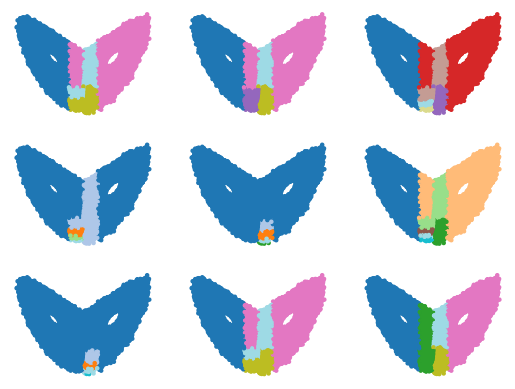

In [35]:
## Run on random splits of the dataa
from operators import transition_matrix, entropy_rate

NUM_ENSEMBLE = 10

X = traj_train.copy()
# tree = recursive_split(X, depth=8)

all_labels = []
all_entropies = []
for i in range(NUM_ENSEMBLE):
    print(f"i: {i}", flush=True)
    np.random.seed(i)

    ## Bag the data
    bootstrap_inds = np.random.choice(X.shape[0], size=X.shape[0], replace=True)
    bootstrap_inds = np.unique(bootstrap_inds) ## Duplicates waste compute
    X_bootstrap = X[bootstrap_inds]
    tree = recursive_split(X_bootstrap, depth=8, min_gain=1e-1)
    labels = labels_for_X(tree, X)

    ## Score the matrix
    P = transition_matrix(labels, vocab_size=len(np.unique(labels)))
    all_entropies.append(entropy_rate(P))
    all_labels.append(labels)
all_labels = np.array(all_labels)

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.scatter(X[:, 0], X[:, 2], c=all_labels[i], cmap='tab20', s=5)
    ## remove axes
    plt.axis('off')



In [36]:
## Make consensusdistance matrix for ensemble
Xe = all_labels[:, :5000]
m, n = Xe.shape
dmat = np.zeros((n, n), dtype=np.uint16 if m < 65535 else np.uint32)
for i in range(m):
    print(f"i: {i}", flush=True)
    xi = Xe[i]
    dmat += (xi[:, None] != xi[None, :])


i: 0
i: 1
i: 2
i: 3
i: 4
i: 5
i: 6
i: 7
i: 8
i: 9


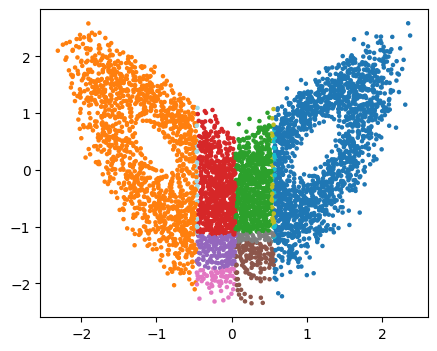

In [37]:
import numpy as np
import igraph as ig
import leidenalg as la

def leiden_from_distance_matrix(
    dmat: np.ndarray,
    *,
    transform: str = "exp",          # "exp" or "inv"
    sigma: float | None = None,      # used for "exp"
    eps: float = 1e-12,              # used for "inv"
    k: int | None = 20,              # if set, build kNN graph (recommended)
    threshold: float | None = None,  # optional: keep only similarities >= threshold
    resolution: float = 1.0,
    seed: int = 0,
) -> np.ndarray:
    """
    Args:
        dmat (np.ndarray): Symmetric (N,N) distance matrix with zeros on the diagonal.
        transform (str): How to convert distance->similarity: "exp" or "inv".
        sigma (float | None): Scale for exp transform; if None, uses median of off-diagonal distances.
        eps (float): Small constant for inverse transform.
        k (int | None): If not None, build a weighted kNN graph; otherwise use all pairs (dense).
        threshold (float | None): Optional similarity cutoff for edges.
        resolution (float): Leiden resolution parameter (higher -> more/smaller communities).
        seed (int): RNG seed for Leiden.

    Returns:
        np.ndarray: Community label per node (length N).
    """
    d = np.asarray(dmat, dtype=float)
    if d.ndim != 2 or d.shape[0] != d.shape[1]:
        raise ValueError("dmat must be a square (N,N) array.")
    if not np.allclose(d, d.T, atol=1e-12, rtol=0):
        raise ValueError("dmat must be symmetric.")

    n = d.shape[0]

    # --- distance -> similarity ---
    if transform == "exp":
        if sigma is None:
            off = d[~np.eye(n, dtype=bool)]
            sigma = np.median(off[off > 0])
            if not np.isfinite(sigma) or sigma <= 0:
                raise ValueError("Could not infer a positive sigma; pass sigma explicitly.")
        s = np.exp(-d / sigma)
    elif transform == "inv":
        s = 1.0 / (d + eps)
    else:
        raise ValueError("transform must be 'exp' or 'inv'.")

    np.fill_diagonal(s, 0.0)  # no self-loops

    # --- build edges (sparse kNN recommended) ---
    edges = []
    weights = []

    if k is not None:
        k = int(k)
        if k <= 0 or k >= n:
            raise ValueError("k must be in [1, N-1].")
        # For each node, connect to k nearest neighbors by distance (excluding self)
        nn_idx = np.argpartition(d, kth=k, axis=1)[:, 1:k+1]  # skip diagonal entry at position 0
        for i in range(n):
            for j in nn_idx[i]:
                if i == j:
                    continue
                w = s[i, j]
                if threshold is not None and w < threshold:
                    continue
                if w > 0:
                    a, b = (i, j) if i < j else (j, i)
                    edges.append((a, b))
                    weights.append(w)
        # Deduplicate edges by keeping max weight if repeated
        if edges:
            from collections import defaultdict
            best = defaultdict(float)
            for (a, b), w in zip(edges, weights):
                if w > best[(a, b)]:
                    best[(a, b)] = w
            edges = list(best.keys())
            weights = [best[e] for e in edges]
    else:
        # Dense: all upper-triangular pairs (may be huge for large N)
        iu, ju = np.triu_indices(n, k=1)
        w = s[iu, ju]
        if threshold is not None:
            m = w >= threshold
            iu, ju, w = iu[m], ju[m], w[m]
        m = w > 0
        edges = list(zip(iu[m].tolist(), ju[m].tolist()))
        weights = w[m].tolist()

    g = ig.Graph(n=n, edges=edges, directed=False)
    g.es["weight"] = weights

    # --- Leiden (use a weighted modularity-type partition) ---
    part = la.find_partition(
        g,
        la.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=resolution,
        seed=seed,
    )
    return np.array(part.membership, dtype=int)

# Example:
metalabels = leiden_from_distance_matrix(
    dmat, transform="exp", sigma=None, k=20, resolution=1.0, seed=0)

plt.figure(figsize=(5, 4))
plt.scatter(X[:5000, 0], X[:5000, 2], c=metalabels, cmap='tab20', s=5)


In [49]:
np.unique(metalabels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

(0.0, 10.0)

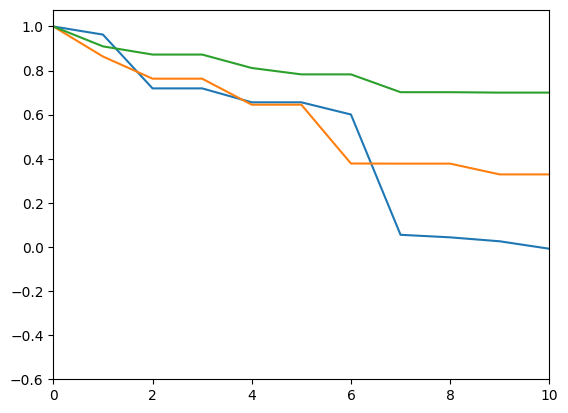

In [57]:
P = transition_matrix(metalabels, vocab_size=len(np.unique(metalabels)))
eigenvalues = np.real(np.linalg.eigvals(P))
sort_order = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort_order][::-1]
plt.plot(eigenvalues)


from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=len(np.unique(metalabels)), random_state=0).fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
P_kmeans = transition_matrix(labels, vocab_size=len(np.unique(labels)))
eigenvalues = np.real(np.linalg.eigvals(P_kmeans))
sort_order = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort_order][::-1]
plt.plot(eigenvalues)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10*len(np.unique(metalabels)), random_state=0).fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
P_kmeans = transition_matrix(labels, vocab_size=len(np.unique(labels)))
eigenvalues = np.real(np.linalg.eigvals(P_kmeans))
sort_order = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort_order][::-1]
plt.plot(eigenvalues)

plt.xlim(0, len(np.unique(metalabels)) - 1)

In [ ]:
# from scipy.spatial.distance import cdist
# dmat_all = np.array(
#     [cdist(all_labels[i][:5000, None], all_labels[i][:5000, None]) for i in range(all_labels.shape[0])]
# )
# dmat = np.sum((dmat_all > 0).astype(int), axis=0)


from sklearn.cluster import HDBSCAN, MiniBatchKMeans, Birch
clusterer = HDBSCAN(
    min_cluster_size=100,
    # min_samples=100,
    metric="precomputed",
)
# clusterer = Birch(
#     n_clusters=None, threshold=0.01, branching_factor=50, 
#     compute_labels=True
# )
metalabels = clusterer.fit_predict(dmat)
# clusterer = MiniBatchKMeans(n_clusters=6, random_state=0, metric="precomputed")
# metalabels = clusterer.fit_predict(dmat)

plt.figure(figsize=(5, 4))
plt.scatter(X[:5000, 0], X[:5000, 2], c=metalabels, cmap='tab20', s=5)


/Users/william/program_repos/lcs/icicl/operators.py:62: RuntimeWarning: divide by zero encountered in log
  row_H = -np.sum(np.where(P > 0, P * (np.log(P) / log_base), 0.0), axis=1)
/Users/william/program_repos/lcs/icicl/operators.py:62: RuntimeWarning: invalid value encountered in multiply
  row_H = -np.sum(np.where(P > 0, P * (np.log(P) / log_base), 0.0), axis=1)


0.5957305787900435


/Users/william/program_repos/dygene/pseudotime/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/william/program_repos/dygene/pseudotime/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/william/program_repos/lcs/icicl/operators.py:62: RuntimeWarning: divide by zero encountered in log
  row_H = -np.sum(np.where(P > 0, P * (np.log(P) / log_base), 0.0), axis=1)
/Users/william/program_repos/lcs/icicl/operators.py:62: RuntimeWarning: invalid value encountered in multiply
  row_H = -np.sum(np.where(P > 0, P * (np.log(P) / log_base), 0.0), axis=1)


0.3364049430859561


IndexError: index 38894 is out of bounds for axis 0 with size 38856

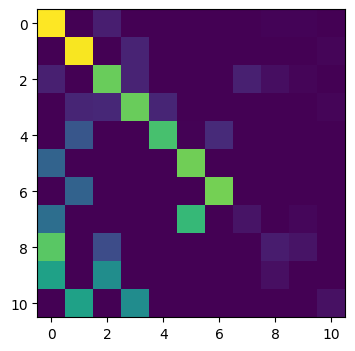

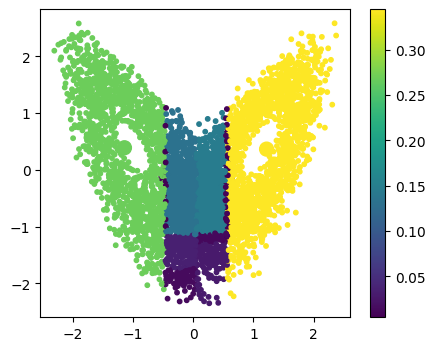

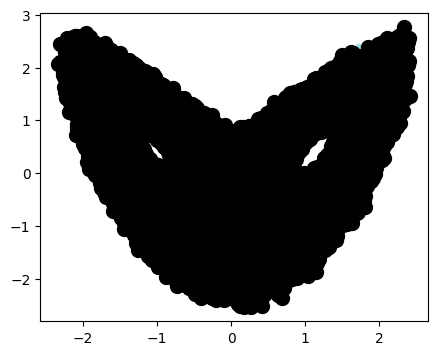

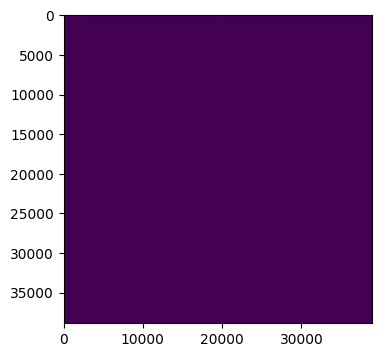

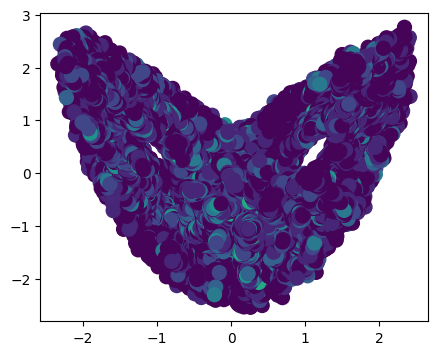

<Figure size 500x400 with 0 Axes>

In [77]:
from operators import transition_matrix, invariant_distribution, entropy_rate

labels = metalabels
# labels = all_labels[1]
# centers = np.array([np.mean(X[labels == i], axis=0) for i in range(len(np.unique(labels)))])

P = transition_matrix(labels, vocab_size=len(np.unique(labels)))
print(entropy_rate(P))
X_subset = X[:len(labels)]
centers = np.array([np.mean(X_subset[labels == i], axis=0) for i in range(len(np.unique(labels)))])

plt.figure(figsize=(4, 4))
plt.imshow(P)

plt.figure(figsize=(5, 4))
plt.scatter(centers[:, 0], centers[:, 2], c=invariant_distribution(P), s=100)

# plt.figure(figsize=(5, 4))
state_sizes = np.array([np.sum(labels == label) for label in np.sort(np.unique(labels))])
# plt.scatter(X_subset[:, 0], X_subset[:, 2], c=invariant_distribution(P)[labels] / state_sizes[labels], s=10)
plt.scatter(X_subset[:, 0], X_subset[:, 2], c=invariant_distribution(P)[labels], s=10)
plt.colorbar()
# # plt.scatter(X[:, 0], X[:, 2], c=invariant_distribution(P)[labels], s=10)

# m2 = invariant_distribution(P)[labels].copy()

from sklearn.cluster import KMeans, Birch
# kmeans = KMeans(n_clusters=3*len(np.unique(labels)), random_state=0).fit(X)
kmeans = Birch(n_clusters=None, threshold=0.01, branching_factor=50, compute_labels=True).fit(X)
labels = kmeans.labels_
# centers = kmeans.cluster_centers_
centers = np.array([np.mean(X[labels == i], axis=0) for i in range(len(np.unique(labels)))])

# from sklearn.cluster import HDBSCAN
# clustering = HDBSCAN(min_cluster_size=10).fit(X)
# labels = clustering.labels_
# # centers = clustering.cluster_centers_

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 2], c=labels, cmap='tab20', s=5)
plt.scatter(centers[:, 0], centers[:, 2], s=100, color='black')

from operators import transition_matrix, invariant_distribution

P = transition_matrix(labels, vocab_size=len(np.unique(labels)))
print(entropy_rate(P))

plt.figure(figsize=(4, 4))
plt.imshow(P)

plt.figure(figsize=(5, 4))
plt.scatter(centers[:, 0], centers[:, 2], c=invariant_distribution(P), s=100)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 2], c=invariant_distribution(P)[labels], s=10)

plt.figure(figsize=(5, 4))
state_sizes = np.array([np.sum(labels == label) for label in np.sort(np.unique(labels))])
plt.scatter(X[:, 0], X[:, 2], c=state_sizes[labels], s=10)

m1 = invariant_distribution(P)[labels].copy()

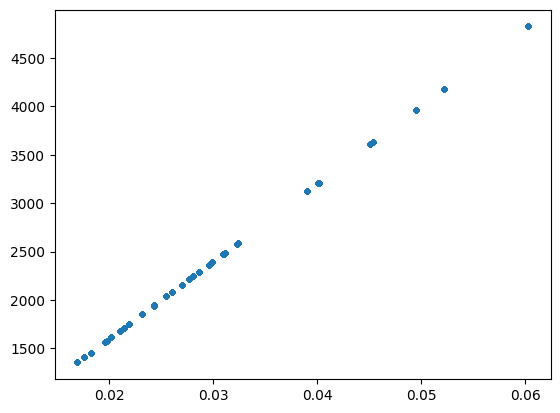

In [70]:
plt.plot(invariant_distribution(P)[labels], state_sizes[labels], '.')

# Appendix

In [ ]:
# naive approach
np.random.seed(0)
# X = np.random.uniform(size=100) # Data time series
X = x_train[:1000].copy()
gaps = (X[1:] + X[:-1]) / 2
X_sorted = np.sort(X)
split_vals = (X_sorted[1:] - X_sorted[:-1]) / 2

def transition_matrix(X, split_val):
    """Given a 1D time series and a threshold, return a row-stochastic transition matrix
    of the binned time series.
    """
    X_bin = (X > split_val).astype(int)
    ## count transitions
    trans_mat = np.zeros((2, 2))
    for i in range(len(X_bin) - 1):
        trans_mat[X_bin[i], X_bin[i+1]] += 1
    
    where_dangle = np.sum(trans_mat, axis=1) == 0
    ## put ones on the diagonal
    # ## Alternative: Fix dangling edges with uniform output
    trans_mat[where_dangle, where_dangle] = 1
    trans_mat = trans_mat / trans_mat.sum(axis=1, keepdims=True)
    return trans_mat

from operators import predictive_information, stationary_entropy, entropy_rate
plt.figure()
plt.plot(
    [predictive_information(transition_matrix(X, split_val)) for split_val in split_vals]
)

plt.figure()
plt.plot(
    [stationary_entropy(transition_matrix(X, split_val)) for split_val in split_vals]
)

plt.figure()
plt.plot(
    [entropy_rate(transition_matrix(X, split_val)) for split_val in split_vals]
)